In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from tqdm import tqdm
from scipy.stats import zscore
from matplotlib.patches import Patch
from scipy.stats import false_discovery_control

from cat_whim.config import PROCESSED_DATA_DIR, INTERIM_DATA_DIR
from cat_whim.diagnostic_lr import *

2024-10-17 16:40:14.628 | INFO     | cat_whim.config:<module>:11 - PROJ_ROOT path is: /home/leoner/Projects/cat_whim


In [3]:
# # Get the regions where 50% or 75% or 90% at least have some disconnection
# def calculate_roi_wmh(df_m00, dk_region_labels):
#     roi_wmh_50 = []
#     roi_wmh_90 = []

#     # For each region in the atlas...
#     for col in dk_region_labels:
#         disconn_col = col + "_disconn"
#         #... check the ratio of subjects that have some degree of disconnection in this region
#         v = (df_m00[disconn_col] == 0).mean()

#         if v >= 0.90: # if the ratio is higher than 75% select this region
#             roi_wmh_90.append(col)
#         if v >= 0.25: # if the ratio is higher than 50% select this region
#             roi_wmh_50.append(col)
#     return roi_wmh_50, roi_wmh_90
def my_regplot(data, x, y, ax):
    import seaborn as sns
    from scipy.stats import linregress
    sns.regplot(data = data, x = x, y = y, ax = ax, scatter_kws = {"s": 8, "alpha":0.4, "color": "black"}, line_kws={"color": "red"})
    # slope, intercept, r, p, stderr = linregress(data[x], data[y])
    # ax.set_title(f"r = {r:.2f}, p = {p:.2f}")

def choose_figure_layout(regions):
    # Determine subplot configuration and figure size based on the number of regions
    if len(regions) == 0:
        pass  # No regions, nothing to plot

    elif len(regions) == 1:
        # One region: create a 1x1 subplot, but figure size remains consistent with a 2x2 grid
        fig, ax = plt.subplots(1, 1, figsize=(3,3))  # Same overall size
        axs_flat = [ax]  # Wrap in list for consistent indexing

    elif 1 < len(regions) <= 4:
        ysize = 3 * len(regions)
        # Up to 4 regions: arrange them in a 1-row grid, still maintaining the total size
        fig, axs = plt.subplots(1, len(regions), figsize=(ysize, 3))  # Same overall size
        axs_flat = axs.flatten()

    else:
        # More than 4 regions: create a grid with 2 rows
        num_cols = (len(regions) + 1) // 2  # Number of columns for 2 rows
        fig, axs = plt.subplots(2, num_cols, figsize=(num_cols*3, 6))  # Same overall size
        axs_flat = axs.flatten()
    
    return fig, axs_flat

def plot_brain_surface_dk(arr_to_plot, fig, ax, cmap, hemisphere="right", view="lateral", binarize=False, colorbar=True):
    import nibabel as nib
    import abagen
    import matplotlib.pyplot as plt

    from nilearn import surface
    from nilearn import plotting
    from nilearn import datasets

    atlas = abagen.fetch_desikan_killiany(surface=True)
    fsaverage = datasets.fetch_surf_fsaverage()
    curv_right = surface.load_surf_data(fsaverage.sulc_right)
    curv_left = surface.load_surf_data(fsaverage.sulc_left)

    dk_lh = nib.load(atlas["image"][0])
    dk_rh = nib.load(atlas["image"][1])
    dk_lh_arr = dk_lh.agg_data()
    dk_rh_arr = dk_rh.agg_data()

    for i in range(0, 34):
        dk_lh_arr = np.where(dk_lh_arr == i+1, arr_to_plot[i], dk_lh_arr)
        dk_rh_arr = np.where(dk_rh_arr == i+42, arr_to_plot[i+34], dk_rh_arr) # deep nuclei are after the left labels, so the right ones don't start from label 35 but from 42
    dk_rh_arr = np.where(dk_rh_arr >= 77, np.nan, dk_rh_arr)
    dk_lh_arr = np.where(dk_lh_arr >= 77, np.nan, dk_lh_arr)
    dk_rh_arr = np.where(dk_rh_arr == 0, np.nan, dk_rh_arr)
    dk_lh_arr = np.where(dk_lh_arr == 0, np.nan, dk_lh_arr)

    if hemisphere == "right":
        if binarize:
        
            ax = plotting.plot_surf(
                fsaverage.infl_right, surf_map=dk_rh_arr, hemi="right", bg_on_data=True, figure=fig, bg_map=curv_right, cmap=cmap, axes=ax, avg_method="median", view= view, colorbar=False, vmin=1, vmax=10)

        else:
            ax = plotting.plot_surf(
                fsaverage.infl_right, surf_map=dk_rh_arr, hemi="right", bg_on_data=True, figure=fig, bg_map=curv_right, cmap=cmap, axes=ax, avg_method="median", view= view, colorbar=colorbar)

    elif hemisphere == "left":
            ax = plotting.plot_surf(
            fsaverage.infl_left, surf_map=dk_lh_arr, hemi="left", bg_on_data=True, figure=fig, bg_map=curv_left, cmap=cmap, axes=ax, avg_method="median", view= view, colorbar=colorbar)

def run_lmm(df, rois, model_type="disconn", apoe=False):
    df_lmm = df.copy()
    rois_arr = np.array(rois)
    
    beta_tau = []
    beta_csvd = []
    beta_csvd_tau = []
    beta_tau_years = []
    beta_csvd_years = []
    beta_csvd_tau_years = []
    
    p_values_tau = []
    p_values_csvd = []
    p_values_csvd_tau = []
    p_values_tau_years = []
    p_values_csvd_years = []
    p_values_csvd_tau_years = []

    for region in rois:

        thickness = region + "_THICKNESS"
        disconn = region + "_disconn"
        tau = region + "_SUVR_tau"

        df_lmm[disconn] = zscore(df_lmm[disconn])
        df_lmm[tau] = zscore(df_lmm[tau])

        if model_type == "disconn":
        
            name = "Disconnection"
    
            if not apoe:
                formula = f"{thickness} ~ {disconn}*{tau}*Years_m00 + AGE + C(HMHYPERT) + PTGENDER + CTX_ETIV_z"
            else:
                formula = f"{thickness} ~ {disconn}*{tau}*Years_m00 + AGE + C(HMHYPERT) + PTGENDER + CTX_ETIV_z + C(APOE4)"
    
            lmm = smf.mixedlm(data=df_lmm, formula=formula, groups=df_lmm["PTID"])
            res = lmm.fit()

            beta_tau.append(res.params[tau])
            beta_csvd.append(res.params[disconn])
            beta_csvd_tau.append(res.params[f"{disconn}:{tau}"])
            beta_tau_years.append(res.params[f"{tau}:Years_m00"])
            beta_csvd_years.append(res.params[f"{disconn}:Years_m00"])
            beta_csvd_tau_years.append(res.params[f"{disconn}:{tau}:Years_m00"])

            p_values_tau.append(res.pvalues[tau])
            p_values_csvd.append(res.pvalues[disconn])
            p_values_csvd_tau.append(res.pvalues[f"{disconn}:{tau}"])
            p_values_tau_years.append(res.pvalues[f"{tau}:Years_m00"])
            p_values_csvd_years.append(res.pvalues[f"{disconn}:Years_m00"])
            p_values_csvd_tau_years.append(res.pvalues[f"{disconn}:{tau}:Years_m00"])
            print(res.summary())            
        
        elif model_type == "wmh":
            name = "WMH"
    
            if not apoe:
                formula = f"{thickness} ~ wmh_vol_log_z*{tau}*Years_m00 + AGE + C(HMHYPERT) + PTGENDER + CTX_ETIV_z"
            else:
                formula = f"{thickness} ~ wmh_vol_log_z*{tau}*Years_m00 + AGE + C(HMHYPERT) + PTGENDER + CTX_ETIV_z + C(APOE4)"
            
            lmm = smf.mixedlm(data=df_lmm, formula=formula, groups=df_lmm["PTID"])
            res = lmm.fit()

            beta_tau.append(res.params[tau])
            beta_csvd.append(res.params["wmh_vol_log_z"])
            beta_csvd_tau.append(res.params[f"wmh_vol_log_z:{tau}"])
            beta_tau_years.append(res.params[f"{tau}:Years_m00"])
            beta_csvd_years.append(res.params[f"wmh_vol_log_z:Years_m00"])
            beta_csvd_tau_years.append(res.params[f"wmh_vol_log_z:{tau}:Years_m00"])

            p_values_tau.append(res.pvalues["wmh_vol_log_z"])
            p_values_csvd.append(res.pvalues["wmh_vol_log_z"])
            p_values_csvd_tau.append(res.pvalues[f"wmh_vol_log_z:{tau}"])
            p_values_tau_years.append(res.pvalues["wmh_vol_log_z:Years_m00"])
            p_values_csvd_years.append(res.pvalues[f"wmh_vol_log_z:Years_m00"])
            p_values_csvd_tau_years.append(res.pvalues[f"wmh_vol_log_z:{tau}:Years_m00"])
            print(res.summary())

    beta_tau_arr = np.array(beta_tau)
    beta_csvd_arr = np.array(beta_csvd)
    beta_csvd_tau_arr = np.array(beta_csvd_tau)
    beta_tau_years_arr = np.array(beta_tau_years)
    beta_csvd_years_arr = np.array(beta_csvd_years)
    beta_csvd_tau_years_arr = np.array(beta_csvd_tau_years)

    p_values_tau_fdr = false_discovery_control(p_values_tau)
    p_values_csvd_fdr = false_discovery_control(p_values_csvd)
    p_values_csvd_tau_fdr = false_discovery_control(p_values_csvd_tau)
    p_values_tau_years_fdr = false_discovery_control(p_values_tau_years)
    p_values_csvd_years_fdr = false_discovery_control(p_values_csvd_years)
    p_values_csvd_tau_years_fdr = false_discovery_control(p_values_csvd_tau_years)

    # Extract the significant regions based on FDR-adjusted p-values
    significant_tau_regions = rois_arr[p_values_tau_fdr < 0.05]
    significant_csvd_regions = rois_arr[p_values_csvd_fdr < 0.05]
    significant_csvd_tau_regions = rois_arr[p_values_csvd_tau_fdr < 0.05]
    significant_tau_years_regions = rois_arr[p_values_tau_years_fdr < 0.05]
    significant_csvd_years_regions = rois_arr[p_values_csvd_years_fdr < 0.05]
    significant_csvd_tau_years_regions = rois_arr[p_values_csvd_tau_years_fdr < 0.05]

    # Print results for the original association
    print(f"{name} is significantly associated with cortical thickness in these areas:")
    for i, reg in enumerate(significant_csvd_regions):
        beta_sig_csvd = beta_csvd_arr[p_values_csvd_fdr < 0.05][i]
        p_sig_csvd = p_values_csvd_fdr[p_values_csvd_fdr < 0.05][i]
        print(f"- {reg}, beta = {beta_sig_csvd:.3f}, p = {p_sig_csvd:.3f} (after FDR)")

    # Print results for tau association
    print(f"\nTau is significantly associated with cortical thickness in these areas:")
    for i, reg in enumerate(significant_tau_regions):
        beta_sig_tau = beta_tau_arr[p_values_tau_fdr < 0.05][i]
        p_sig_tau = p_values_tau_fdr[p_values_tau_fdr < 0.05][i]
        print(f"- {reg}, beta = {beta_sig_tau:.3f}, p = {p_sig_tau:.3f} (after FDR)")

    # Print results for the {name} * tau interaction
    print(f"\n{name} * tau is significantly associated with cortical thickness in these areas:")
    for i, reg in enumerate(significant_csvd_tau_regions):
        beta_sig_csvd_tau = beta_csvd_tau_arr[p_values_csvd_tau_fdr < 0.05][i]
        p_sig_csvd_tau = p_values_csvd_tau_fdr[p_values_csvd_tau_fdr < 0.05][i]
        print(f"- {reg}, beta = {beta_sig_csvd_tau:.3f}, p = {p_sig_csvd_tau:.3f} (after FDR)")

    # Print results for the {name} * Years interaction
    print(f"\n{name} * Years is significantly associated with cortical thickness in these areas:")
    for i, reg in enumerate(significant_csvd_years_regions):
        beta_sig_csvd_years = beta_csvd_years_arr[p_values_csvd_years_fdr < 0.05][i]
        p_sig_csvd_years = p_values_csvd_years_fdr[p_values_csvd_years_fdr < 0.05][i]
        print(f"- {reg}, beta = {beta_sig_csvd_years:.3f}, p = {p_sig_csvd_years:.3f} (after FDR)")

    
    # Print results for the tau * Years interaction
    print(f"\nTau * Years is significantly associated with cortical thickness in these areas:")
    for i, reg in enumerate(significant_tau_years_regions):
        beta_sig_tau_years = beta_csvd_years_arr[p_values_tau_years_fdr < 0.05][i]
        p_sig_tau_years = p_values_tau_years_fdr[p_values_tau_years_fdr < 0.05][i]
        print(f"- {reg}, beta = {beta_sig_tau_years:.3f}, p = {p_sig_tau_years:.3f} (after FDR)")

    # Print results for the {name} * tau * Years interaction
    print(f"\n{name} * tau * Years is significantly associated with cortical thickness in these areas:")
    for i, reg in enumerate(significant_csvd_tau_years_regions):
        beta_sig_csvd_tau_years = beta_csvd_tau_years_arr[p_values_csvd_tau_years_fdr < 0.05][i]
        p_sig_csvd_tau_years = p_values_csvd_tau_years_fdr[p_values_csvd_tau_years_fdr < 0.05][i]
        print(f"- {reg}, beta = {beta_sig_csvd_tau_years:.3f}, p = {p_sig_csvd_tau_years:.3f} (after FDR)")
    print()

    return significant_csvd_regions, significant_csvd_tau_regions, significant_csvd_years_regions,significant_csvd_tau_years_regions

# Main analyses

In [4]:
# Change to df_cat_whim_to_analyze_complete_apoe.csv in case you want only ptids with complete info
df_filename = PROCESSED_DATA_DIR / "df_cat_whim_to_analyze.csv"
dk_regions_filename = PROCESSED_DATA_DIR / "dk_region_names.csv"
roi_adsig_filename = PROCESSED_DATA_DIR / "ad_signature_mayo_rois.csv"
# roi_schwarz_filename = PROCESSED_DATA_DIR / "schwarz_rois.csv"

# Load data
df = pd.read_csv(df_filename)
df = df[df["session"]!="M02"].reset_index(drop=True).copy()
df = df[df["DX"]!= "Dementia"].reset_index(drop=True).copy()
dk_region_labels = pd.read_csv(dk_regions_filename).values.flatten()

adsig_mayo = pd.read_csv(roi_adsig_filename).columns.to_list() # ADsig Mayo from Clifford et al Brain 2015 (as reported by Parker et al in Alzh & Dem)
# schwarz = pd.read_csv(roi_schwarz_filename).columns.to_list() # ADsig Mayo from Schwarz et al NeuroImage:Clinical 2016

# Get the region names for each biomarker
amy_cols = [region + "_SUVR_amy" for region in dk_region_labels]
tau_cols = [region + "_SUVR_tau" for region in dk_region_labels]
disconn_cols = [region + "_disconn" for region in dk_region_labels]
thick_cols = [region + "_THICKNESS" for region in dk_region_labels]

# Load the wmh data
wmh = pd.read_csv(INTERIM_DATA_DIR / "df_wmh_vols.csv")
wmh["session"] = wmh["session"].apply(lambda x: x.split("-")[1])
df = df.merge(wmh, on = ["PTID", "session"])
df["wmh_vol_log"] = np.log10(df["wmh_vol"], where=(df["wmh_vol"]!=0), out=np.zeros_like(df["wmh_vol"]))

# Calculate the signature roi values
df["mean_adsig_mayo_THICKNESS"] = df[[col+"_THICKNESS" for col in adsig_mayo]].mean(axis=1)
df["mean_adsig_mayo_disconn"] = df[[col+"_disconn" for col in adsig_mayo]].mean(axis=1)
df["mean_adsig_mayo_SUVR_tau"] = df[[col+"_SUVR_tau" for col in adsig_mayo]].mean(axis=1)
df["mean_adsig_mayo_SUVR_amy"] = df[[col+"_SUVR_amy" for col in adsig_mayo]].mean(axis=1)

# z-score stuff
df["mean_adsig_mayo_THICKNESS_z"] = zscore(df["mean_adsig_mayo_THICKNESS"])
df["mean_adsig_mayo_disconn_z"] = zscore(df["mean_adsig_mayo_disconn"])
df["mean_adsig_mayo_SUVR_tau_z"] = zscore(df["mean_adsig_mayo_SUVR_tau"])
df["mean_adsig_mayo_SUVR_amy_z"] = zscore(df["mean_adsig_mayo_SUVR_amy"])

df["CTX_ETIV_z"] = zscore(df["CTX_ETIV"])
df["wmh_vol_log_z"] = zscore(df["wmh_vol_log"])

/home/leoner/miniconda3/envs/cat_whim/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [5]:
print("List included in the mask:")
print(adsig_mayo)

List included in the mask:
['CTX_LH_ENTORHINAL', 'CTX_LH_FUSIFORM', 'CTX_LH_INFERIORTEMPORAL', 'CTX_LH_MIDDLETEMPORAL', 'CTX_RH_ENTORHINAL', 'CTX_RH_FUSIFORM', 'CTX_RH_INFERIORTEMPORAL', 'CTX_RH_MIDDLETEMPORAL']


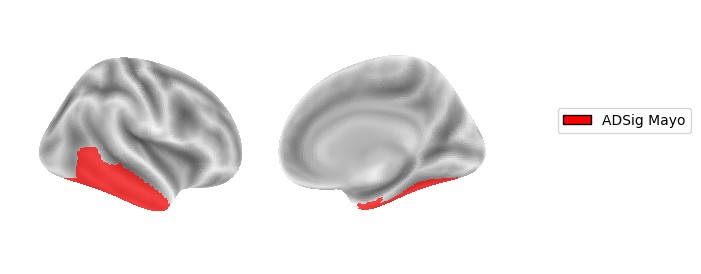

In [6]:
# Just to show regions on the brain surface
adsig_mayo_plot = []

for region in dk_region_labels:
    if region in adsig_mayo:
        adsig_mayo_plot.append(1)
    else:
        adsig_mayo_plot.append(0)

fig, axes = plt.subplots(1, 2, subplot_kw = {"projection": "3d"})

plot_brain_surface_dk(adsig_mayo_plot, fig, axes[0], "autumn", hemisphere="right", view="lateral", binarize=True)
plot_brain_surface_dk(adsig_mayo_plot, fig, axes[1], "autumn", hemisphere="right", view="medial", binarize=True)
# Create custom legend elements
legend_elements = [
    Patch(facecolor=plt.cm.autumn(0), edgecolor='k', label='ADSig Mayo'),
]

# Add the legend to the figure
fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.2, 0.57))
fig.subplots_adjust(wspace=-0.05)

<Axes: xlabel='wmh_vol_log_z', ylabel='Count'>

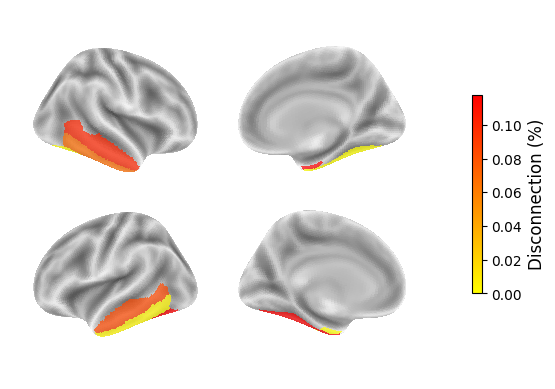

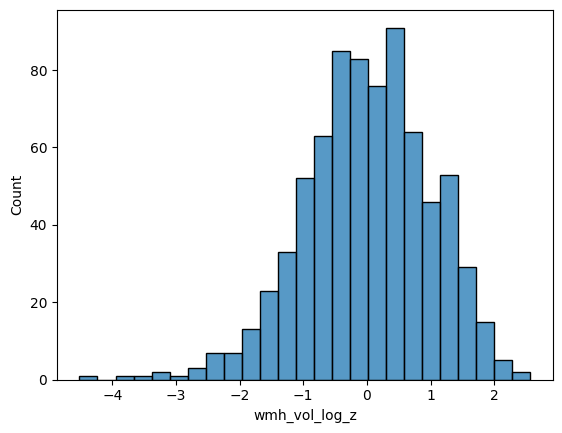

In [7]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import seaborn as sns

discon_plot = []
thickness_plot = []

for region in dk_region_labels:
    disconn = region + "_disconn"
    thickness = region + "_THICKNESS"
    if region in adsig_mayo:
        discon_plot.append(df[disconn].mean())
        thickness_plot.append(df[thickness].mean())
    else:
        discon_plot.append(0)
        thickness_plot.append(0)


# Assuming discon_plot is already created as per your initial code

# Define the colormap and normalization based on discon_plot values
norm = Normalize(vmin=min(discon_plot), vmax=max(discon_plot))  # Normalize values
# Create a scalar mappable for the colorbar
sm = cm.ScalarMappable(cmap="autumn_r", norm=norm)
sm.set_array([])  # This is needed to associate the scalar mappable with a colormap
# Create the figure and plot
fig, axes = plt.subplots(2, 2, subplot_kw = {"projection": "3d"})
plot_brain_surface_dk(discon_plot, fig, axes[0,0], "autumn_r", hemisphere="right", view="lateral", colorbar=False)
plot_brain_surface_dk(discon_plot, fig, axes[0,1], "autumn_r", hemisphere="right", view="medial", colorbar=False)
plot_brain_surface_dk(discon_plot, fig, axes[1,0], "autumn_r", hemisphere="left", view="lateral", colorbar=False)
plot_brain_surface_dk(discon_plot, fig, axes[1,1], "autumn_r", hemisphere="left", view="medial", colorbar=False)
# Make brains closer to each other
fig.subplots_adjust(wspace=-0.1, hspace=-0.2)
# Add the colorbar and change the label
cbar = fig.colorbar(sm, ax=axes, orientation="vertical", fraction=0.02, pad=0.1)
cbar.set_label("Disconnection (%)", fontsize=12)
# Plot the histogram of WMH
fig, ax = plt.subplots(1, 1)
sns.histplot(data=df, x = "wmh_vol_log_z", ax = ax)

WMH were log transformed to approximate a normal distribution.

# Primary analyses:
In the whole cohort, for all regions in the ADSig mask, we run linear mixed models with the following formula for disconnections (all predictors and the intracranial volume are z-scored to bring them to the same scale):

*disconn formula = f"{thickness} ~ {disconn}:{tau}:{amy}:Years_m00 + AGE + C(HMHYPERT) + PTGENDER + CTX_ETIV_z"* 

And for the total WMH volume (log transformed):

*wmh formula = f"{thickness} ~ wmh_vol_log_z:{tau}_{amy}:Years_m00 + AGE + C(HMHYPERT) + PTGENDER + CTX_ETIV_z"*

The parameters for disconn * Years_m00, tau * Years_m00, etc. consider the longitudinal effects on cortical thickness
(same for wmh)

See below for the ones including amyloid.

In [8]:
sig_disconn_regions, sig_disconn_tau_regions, sig_disconn_years_regions,sig_disconn_tau_years_regions = run_lmm(df, adsig_mayo, model_type="disconn")

                                  Mixed Linear Model Regression Results
Model:                        MixedLM           Dependent Variable:           CTX_LH_ENTORHINAL_THICKNESS
No. Observations:             756               Method:                       REML                       
No. Groups:                   614               Scale:                        0.0076                     
Min. group size:              1                 Log-Likelihood:               -76.0348                   
Max. group size:              2                 Converged:                    Yes                        
Mean group size:              1.2                                                                        
---------------------------------------------------------------------------------------------------------
                                                               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------

In [9]:
sig_wmh_regions, sig_wmh_tau_regions, sig_wmh_years_regions,sig_wmh_tau_years_regions = run_lmm(df, adsig_mayo, model_type="wmh")

                            Mixed Linear Model Regression Results
Model:                    MixedLM       Dependent Variable:       CTX_LH_ENTORHINAL_THICKNESS
No. Observations:         756           Method:                   REML                       
No. Groups:               614           Scale:                    0.0078                     
Min. group size:          1             Log-Likelihood:           -80.8061                   
Max. group size:          2             Converged:                Yes                        
Mean group size:          1.2                                                                
---------------------------------------------------------------------------------------------
                                                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------------------
Intercept                                           3.520    0.125 28.173 0.000  3.275  

These are cross-sectional graph for illustratory purposes only


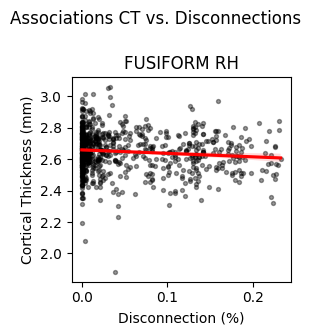

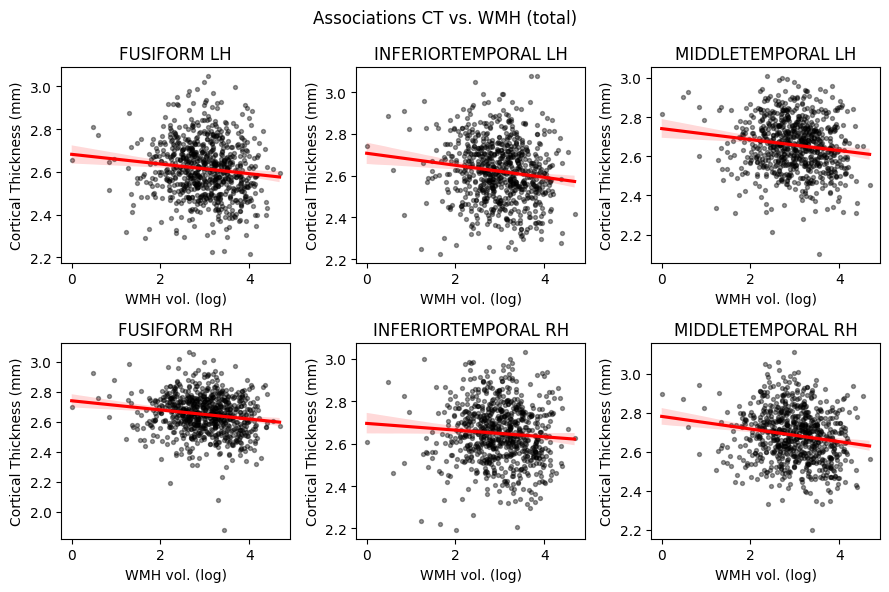

In [10]:
print("These are cross-sectional graph for illustratory purposes only")

# Plot the data
fig, axs_flat = choose_figure_layout(sig_disconn_regions)
for i, region in enumerate(sig_disconn_regions):
    region_name = region.split("_")[-1] + " " + region.split("_")[-2]
    thickness = region + "_THICKNESS"
    disconn = region + "_disconn"
    
    # Use the appropriate axis for each plot
    my_regplot(data=df, x=disconn, y=thickness, ax=axs_flat[i])
    axs_flat[i].set_xlabel("Disconnection (%)")
    axs_flat[i].set_ylabel("Cortical Thickness (mm)")
    axs_flat[i].set_title(region_name)
fig.tight_layout()

fig.suptitle("Associations CT vs. Disconnections", x = 0.5, y = 1.1)

fig, axs_flat = choose_figure_layout(sig_wmh_regions)
for i, region in enumerate(sig_wmh_regions):
    region_name = region.split("_")[-1] + " " + region.split("_")[-2]
    
    thickness = region + "_THICKNESS"
    
    # Use the appropriate axis for each plot
    my_regplot(data=df, x="wmh_vol_log", y=thickness, ax=axs_flat[i])
    axs_flat[i].set_xlabel("WMH vol. (log)")
    axs_flat[i].set_ylabel("Cortical Thickness (mm)")
    axs_flat[i].set_title(region_name)

fig.suptitle("Associations CT vs. WMH (total)", x = 0.5, y = 0.98)
fig.tight_layout()


# Sensitivity analyses

Only amyloid + subjects

In [11]:
# Same formulas as before
df_amy_plus = df[df["AMYLOID_STATUS"] == 1].copy()
print(f"There are now {df_amy_plus['PTID'].nunique()} subjects, among which {df_amy_plus[df_amy_plus['session'] == 'M01']['PTID'].nunique()} with follow-up\n")
sig_disconn_regions, sig_disconn_tau_regions, sig_disconn_years_regions,sig_disconn_tau_years_regions = run_lmm(df_amy_plus, adsig_mayo, model_type="disconn")

There are now 246 subjects, among which 69 with follow-up



                                  Mixed Linear Model Regression Results
Model:                        MixedLM           Dependent Variable:           CTX_LH_ENTORHINAL_THICKNESS
No. Observations:             300               Method:                       REML                       
No. Groups:                   246               Scale:                        0.0073                     
Min. group size:              1                 Log-Likelihood:               -39.1689                   
Max. group size:              2                 Converged:                    Yes                        
Mean group size:              1.2                                                                        
---------------------------------------------------------------------------------------------------------
                                                               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------

In [12]:
sig_wmh_regions, sig_wmh_tau_regions, sig_wmh_years_regions,sig_wmh_tau_years_regions = run_lmm(df_amy_plus, adsig_mayo, model_type="wmh")

                            Mixed Linear Model Regression Results
Model:                    MixedLM       Dependent Variable:       CTX_LH_ENTORHINAL_THICKNESS
No. Observations:         300           Method:                   REML                       
No. Groups:               246           Scale:                    0.0083                     
Min. group size:          1             Log-Likelihood:           -45.2820                   
Max. group size:          2             Converged:                Yes                        
Mean group size:          1.2                                                                
---------------------------------------------------------------------------------------------
                                                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------------------
Intercept                                           3.515    0.209 16.828 0.000  3.106  

Only in the subset with APOE, now formula is:

*formula = f"{thickness}/wmh ~ {disconn}:{tau}:Years_m00 + AGE + C(HMHYPERT) + PTGENDER + CTX_ETIV_z + C(APOE4)"*


In [13]:
df_apoe = df.dropna(subset="APOE4").copy()
print(f"There are now {df_apoe['PTID'].nunique()} subjects, among which {df_apoe[df_apoe['session'] == 'M01']['PTID'].nunique()} with follow-up \n")
sig_disconn_regions, sig_disconn_tau_regions, sig_disconn_years_regions,sig_disconn_tau_years_regions = run_lmm(df_apoe, adsig_mayo, model_type="disconn", apoe=True)

There are now 510 subjects, among which 141 with follow-up 

                                  Mixed Linear Model Regression Results
Model:                        MixedLM           Dependent Variable:           CTX_LH_ENTORHINAL_THICKNESS
No. Observations:             650               Method:                       REML                       
No. Groups:                   510               Scale:                        0.0078                     
Min. group size:              1                 Log-Likelihood:               -47.5107                   
Max. group size:              2                 Converged:                    Yes                        
Mean group size:              1.3                                                                        
---------------------------------------------------------------------------------------------------------
                                                               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------

In [14]:
sig_wmh_regions, sig_wmh_tau_regions, sig_wmh_years_regions,sig_wmh_tau_years_regions = run_lmm(df_apoe, adsig_mayo, model_type="wmh", apoe=True)

                            Mixed Linear Model Regression Results
Model:                    MixedLM       Dependent Variable:       CTX_LH_ENTORHINAL_THICKNESS
No. Observations:         650           Method:                   REML                       
No. Groups:               510           Scale:                    0.0080                     
Min. group size:          1             Log-Likelihood:           -52.1457                   
Max. group size:          2             Converged:                Yes                        
Mean group size:          1.3                                                                
---------------------------------------------------------------------------------------------
                                                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------------------
Intercept                                           3.609    0.142 25.385 0.000  3.330  